In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.impute import SimpleImputer

In [91]:
DATA_DIR = "../../data/raw/final_dataset.csv"

# adjust to not use much memory, i just crashed my desktop
CHUNK_SIZE = 200_000
MAX_LABEL = 100_000

In [92]:
counts = {}
parts = []

for chunk in pd.read_csv(DATA_DIR, chunksize=CHUNK_SIZE):
    for label, group in chunk.groupby("Label"):
        n = counts.get(label, 0)
        if n >= MAX_LABEL:
            continue

        group_shuffled = group.sample(frac=1, random_state=1)
        take = group_shuffled.iloc[: MAX_LABEL - n]

        # iloc is "integer location", just row by position exactly like array slicing
        take = group_shuffled.iloc[: MAX_LABEL - n]
        parts.append(take)
        counts[label] = n + len(take)

    # stop once we have two labels and MAX_LABEL rows for each
    if len(counts) == 2 and all(c >= MAX_LABEL for c in counts.values()):
        break

# ignore_index resets row numbers, so we go from 0..MAX_LABEL*2
df = pd.concat(parts, ignore_index=True)
df = df.sample(frac=1, random_state=1).reset_index(drop=True)
# dataframes let you index by column
print(df["Label"].value_counts())

Label
ddos      100000
Benign    100000
Name: count, dtype: int64


In [93]:
"""
Numeric features:
    Because kNN uses stuff like Euclidean difference for distances, it relies of course on numeric points.
    Therefore we drop columns that are either non-numeric or irrelevant.

    NOTE: I think src IP is irrelevant as this is a _distributed_ dos but maybe it isn't?
          Timestamp may also be relevant, but probably not because of the same reason. Multiple people visiting
          in quick successsion doesn't mean a ddos itself.
"""

df_features = df.copy()

columns_to_drop = [
    "Label",
    "Unnamed: 0",
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Timestamp",
    "Src Port",
    "Dst Port",
]
df_features = df_features.drop(columns=columns_to_drop)

# One-hot encode Protocol (categorical variable)
# This converts Protocol into dummy variables: Protocol_6, Protocol_17, etc.
df_features = pd.get_dummies(df_features, columns=["Protocol"], prefix="Protocol")

X = df_features.values
y = df["Label"].values

# sklearn needs numeric labels so 1 for 'ddos' 0 for 'Benign'
y_numeric = np.where(y == "ddos", 1, 0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Label vector shape: {y_numeric.shape}")
print(f"Number of features: {X.shape[1]}")


Feature matrix shape: (200000, 79)
Label vector shape: (200000,)
Number of features: 79


In [94]:
"""
Cleaning:
   There were some issues with inf being present, so we replace those with NaN.
   Then we replace NaN with column median. Median is better than mean wrt outliers.
"""

X = X.astype(np.float64)
X = np.where(np.isinf(X), np.nan, X)

imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

In [95]:
"""
Splitting data:
  - 60% training
  - 20% validation (we'll tune hyperparameters here)
  - 20% test
"""

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y_numeric,
    test_size=0.2,
    random_state=1,  # Seeded so we can reproduce
    stratify=y_numeric,  # Split across 'ddos' and 'Benign'
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)

In [96]:
"""
Feature scaling:
    Because we're working with distances we wanna do some scaling.
    `StandardScaler` gives us mean 0, stddev 1, which sounds good to me.
    We fit the scaler only on training data, and then transform all data using it.
    If our training data is representative then this works.
"""

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(
    f"Training data mean: {X_train_scaled.mean():.6f} should be 0, stddev: {X_train_scaled.std():.6f} should be 1."
)

Training data mean: 0.000000 should be 0, stddev: 0.948016 should be 1.


In [97]:
"""
Hyperparameter tuning:
    We're changing `k`, the number of neighbours.
    Small `k` is sensitive to noise and can overfit.
    Big `k` can underfit but generally better I think?
"""

k_values = range(1, 51, 2)  # odd numbers apparently better
val_accuracies = []
train_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Evaluate on training set, which checks for overfitting.
    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    train_accuracies.append(train_acc)

    # Evaluate on validation set, to find best hyperparameter.
    val_acc = accuracy_score(y_val, knn.predict(X_val_scaled))
    val_accuracies.append(val_acc)

# Best k based on accuracy.
best_k_idx = np.argmax(val_accuracies)
best_k = list(k_values)[best_k_idx]
best_val_acc = val_accuracies[best_k_idx]

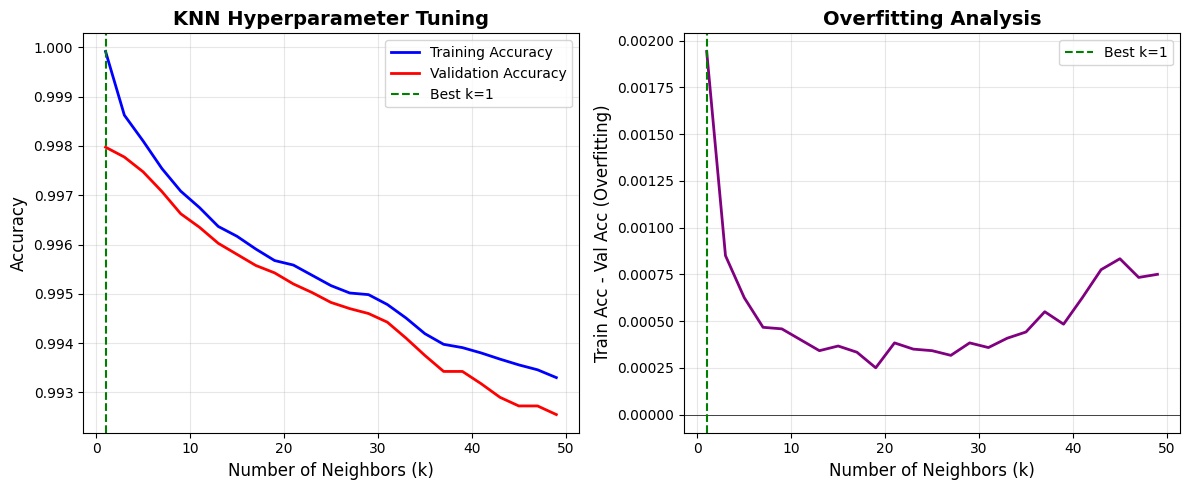

In [98]:
"""
Visualising:
    Accuracy versus k to visually see which is best and if there are trends that'll reveal
"""

plt.figure(figsize=(12, 5))

# Accuracy vs k
plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies, "b-", label="Training Accuracy", linewidth=2)
plt.plot(k_values, val_accuracies, "r-", label="Validation Accuracy", linewidth=2)
plt.axvline(x=best_k, color="g", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("Number of Neighbors (k)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("KNN Hyperparameter Tuning", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)

# Diff between training/validation (overfitting)
plt.subplot(1, 2, 2)
overfit_gap = np.array(train_accuracies) - np.array(val_accuracies)
plt.plot(k_values, overfit_gap, "purple", linewidth=2)
plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
plt.axvline(x=best_k, color="g", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("Number of Neighbors (k)", fontsize=12)
plt.ylabel("Train Acc - Val Acc (Overfitting)", fontsize=12)
plt.title("Overfitting Analysis", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../../plots/hyperparameter_tuning.png", dpi=300, bbox_inches="tight")

In [99]:
"""
Training
"""

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [100]:
"""
Evaluate on test data:
    We do this only once!!!
"""

y_test_pred = final_knn.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test, y_test_pred, target_names=["Benign", "DDoS"], digits=4
    )
)


Test Accuracy: 0.9980

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9986    0.9973    0.9980     20000
        DDoS     0.9974    0.9987    0.9980     20000

    accuracy                         0.9980     40000
   macro avg     0.9980    0.9980    0.9980     40000
weighted avg     0.9980    0.9980    0.9980     40000



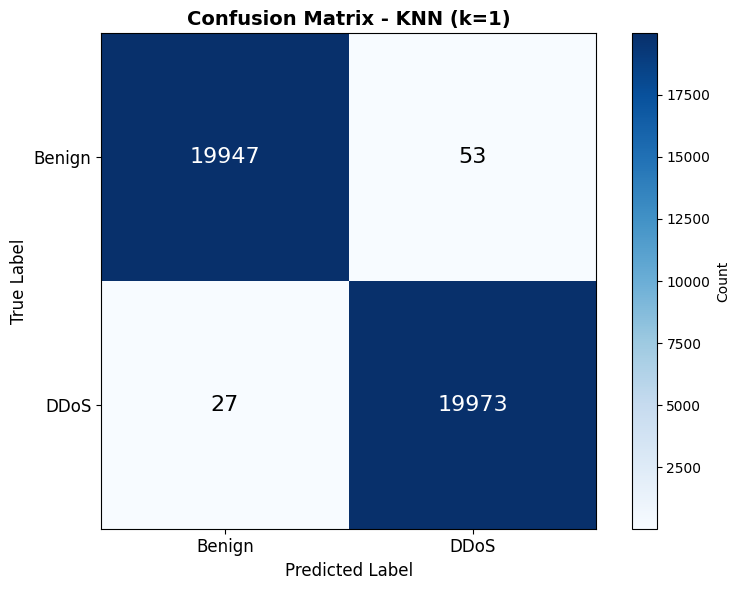

In [101]:
"""
Confusion matrix:
    We can use this to then make a ROC and AUC to see TPR/FPR and performance
"""

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix - KNN (k={best_k})", fontsize=14, fontweight="bold")
plt.colorbar(label="Count")

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=16,
        )

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Benign", "DDoS"], fontsize=12)
plt.yticks(tick_marks, ["Benign", "DDoS"], fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("../../plots/confusion_matrix.png", dpi=300, bbox_inches="tight")


ROC AUC Score: 0.9980


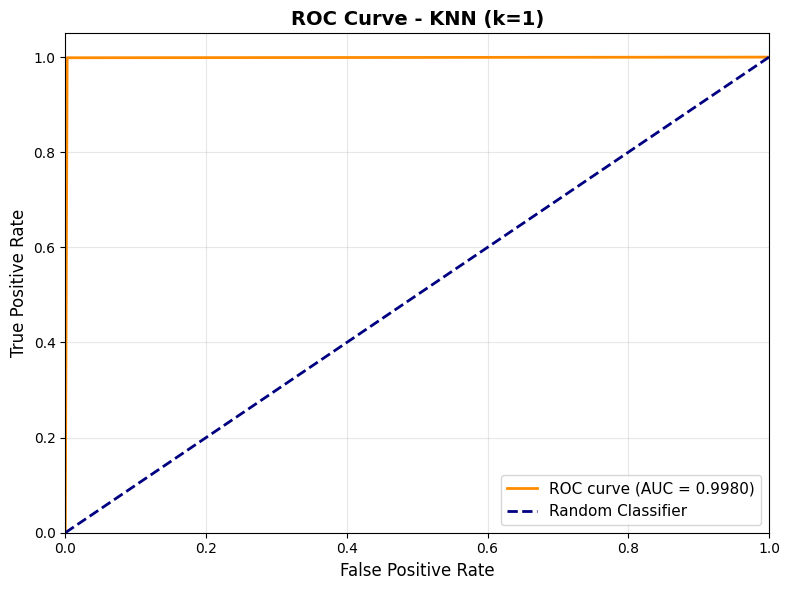

In [102]:
"""
ROC and AUC:
    ROC shows tradeoff between TPR and FPR.
    AUC shows overall performance, with 1 perfect and 0.5 random.
    NOTE: something to talk about in report is how much we actually care about TPR and FPR.
"""

y_test_proba = final_knn.predict_proba(X_test_scaled)[:, 1]  # prob of ddos (label 1)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr, color="darkorange", linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1], [0, 1], color="navy", linewidth=2, linestyle="--", label="Random Classifier"
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title(f"ROC Curve - KNN (k={best_k})", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../plots/roc_curve.png", dpi=300, bbox_inches="tight")

print(f"\nROC AUC Score: {roc_auc:.4f}")

In [103]:
"""
Cross validation:
    We do 5-fold CV. I assume this is splitting validation set into 5 pieces, but it might be a sliding window?
    We do it with combined train/validation because we're already done with hyperparameters and more data = good.
"""

X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

cv_scores = cross_val_score(final_knn, X_trainval, y_trainval, cv=5, scoring="accuracy")

print(f"Scores per fold: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Scores per fold: [0.998      0.99790625 0.99803125 0.998125   0.99803125]
Mean CV Accuracy: 0.9980 (+/- 0.0001)


In [104]:
print(f"Dataset Size: {len(X)} samples")
print(f"Features: {X.shape[1]}")
print(f"Classes: Benign (0), DDoS (1)")
print(f"\nBest k value: {best_k}")
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"CV Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

plt.show()

Dataset Size: 200000 samples
Features: 79
Classes: Benign (0), DDoS (1)

Best k value: 1
Validation Accuracy: 0.9980
Test Accuracy: 0.9980
ROC AUC: 0.9980
CV Mean Accuracy: 0.9980 (+/- 0.0001)
